# Stationarity, reversibility, currents, and mixing

This notebook separates two questions that are often conflated. Stationarity asks whether the target law is invariant. Mixing asks how quickly the chain forgets its initial state. Detailed balance is sufficient for stationarity but not necessary.

In [1]:
CHAPTER_DIR = "ch08"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## Reversible and irreversible chains with the same target

We use the uniform law on a four-state cycle. A lazy symmetric walk is reversible. A biased lazy walk has a persistent clockwise current, violates detailed balance, but still satisfies global balance.

reversible detailed-balance defect 0.0
irreversible detailed-balance defect 0.125


Saved: figs/ch08_01_reversible_and_irreversible_chains.pdf


Saved: figs/ch08_01_reversible_and_irreversible_chains.png


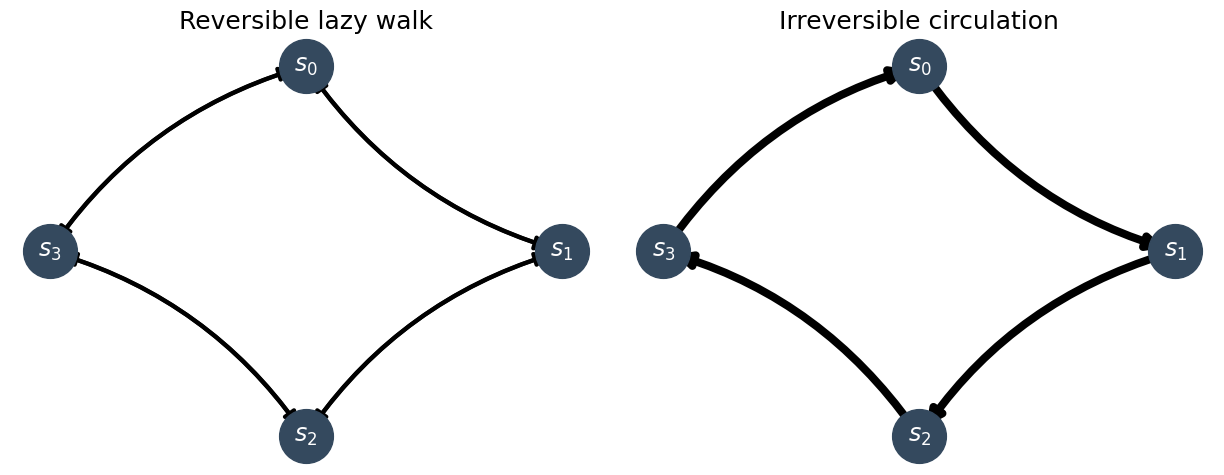

In [2]:
pi=np.ones(4)/4
P_rev=np.zeros((4,4)); P_irr=np.zeros((4,4))
for i in range(4):
    P_rev[(i+1)%4,i]=.25; P_rev[(i-1)%4,i]=.25; P_rev[i,i]=.5
    P_irr[(i+1)%4,i]=.55; P_irr[(i-1)%4,i]=.05; P_irr[i,i]=.40
for P in [P_rev,P_irr]:
    assert np.allclose(P.sum(axis=0),1); assert np.allclose(P@pi,pi)
Qrev=P_rev*pi[np.newaxis,:]; Qirr=P_irr*pi[np.newaxis,:]
print('reversible detailed-balance defect',np.max(abs(Qrev-Qrev.T)))
print('irreversible detailed-balance defect',np.max(abs(Qirr-Qirr.T)))

G=nx.DiGraph(); G.add_nodes_from(range(4)); pos={0:(1,1),1:(2,0),2:(1,-1),3:(0,0)}
fig,axes=plt.subplots(1,2,figsize=(12.5,5))
for ax,P,title in zip(axes,[P_rev,P_irr],['Reversible lazy walk','Irreversible circulation']):
    nx.draw_networkx_nodes(G,pos,node_size=1500,node_color=NODE_COLOR,ax=ax); nx.draw_networkx_labels(G,pos,labels={i:rf'$s_{i}$' for i in range(4)},font_color='white',font_size=17,ax=ax)
    for i in range(4):
        for j in range(4):
            if i!=j and P[j,i]>.001:
                nx.draw_networkx_edges(G,pos,edgelist=[(i,j)],arrows=True,arrowsize=20,width=0.8+9*P[j,i],connectionstyle=('arc3,rad=.18' if j>i else 'arc3,rad=-.18'),ax=ax)
    ax.set_title(title); ax.axis('off')
fig.tight_layout(); save_figure(fig,'ch08_01_reversible_and_irreversible_chains'); plt.show()

## Total-variation convergence

For a finite irreducible aperiodic chain, convergence is governed by the nontrivial spectrum, but nonnormal irreversible chains require care: eigenvalues alone do not describe every transient.

Saved: figs/ch08_01_total_variation_mixing.pdf
Saved: figs/ch08_01_total_variation_mixing.png


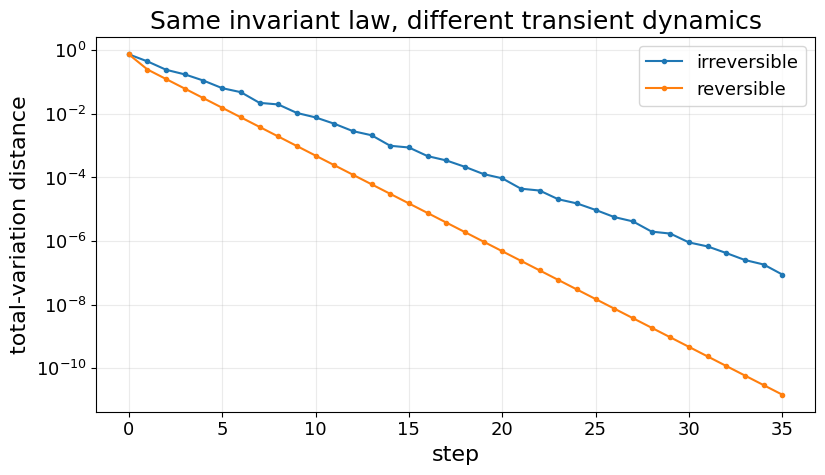

In [3]:
def tv(p,q): return .5*np.abs(p-q).sum()
T=35; init=np.array([1.,0,0,0]); rows=[]
for name,P in [('reversible',P_rev),('irreversible',P_irr)]:
    p=init.copy()
    for t in range(T+1): rows.append((name,t,tv(p,pi))); p=P@p
df=pd.DataFrame(rows,columns=['chain','time','TV'])
fig,ax=plt.subplots(figsize=(8.5,5));
for name,g in df.groupby('chain'): ax.semilogy(g.time,g.TV,marker='o',markersize=3,label=name)
ax.set_xlabel('step'); ax.set_ylabel('total-variation distance'); ax.set_title('Same invariant law, different transient dynamics'); ax.legend(); ax.grid(alpha=.25); fig.tight_layout(); save_figure(fig,'ch08_01_total_variation_mixing'); plt.show()

## Exercises

1. Compute the stationary currents $J_{ij}=P_{ij}\pi_j-P_{ji}\pi_i$.
2. Remove laziness and identify the resulting periodicity.
3. Construct a nonuniform target distribution and an irreversible globally balanced chain preserving it.